## Pregunta 4.

####  ¿Está relacionado el hecho de pagar **comisiones más altas** con la obtención de una **rentabilidad superior**? 
---



#### Índice


1. Lectura de datos ya procesados.
2. Cálculo de rentabilidad neta acumulada y estudio de resultados.
3. Nuevo dataframe dividido según calificación de gastos.
4. Visualización de gráficas y estudio de resultados.
    - Gráficas
    - Fondo **ejemplo** y fondo **fracaso**
    


---

In [13]:
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional

### 1. Lectura de datos previamente procesados
 - Los datos que aquí tratamos provienen del módulo de limpieza de datos de fondos.

In [ ]:
df = pd.read_excel('../data/Excel_final_fondos.xlsx', index_col= 0)

# Pasamos a numérico los gastos corrientes, ya que se quedan tipo object
df['Gastos Corrientes'] = pd.to_numeric(df['Gastos Corrientes'], errors='coerce')
df.head()

,Nombre del Fondo,ISIN,PRECIO PARTICIPACIÓN,rent 2024,rent 2023,rent 2022,rent 2021,rent 2020,rent 2019,rent 2018,rent 2017,Gasto De Gestión Max Anual,Gastos Corrientes,Volatilidad
0,AB - Emerging Markets Low Volatility Equity Po...,LU1005412462,"USD 24,77",0.1778,0.1454,-0.1763,0.0533,0.0683,0.1808,-0.1252,0.1674,0.0085,0.0115,0.1234
1,AB - Select US Equity Portfolio S1 USD Acc,LU0683601610,"USD 85,96",0.3560,0.1507,-0.0820,0.3998,0.0596,0.3168,-0.0012,0.0737,0.0075,0.0082,0.1356
2,AB - Select US Equity Portfolio W USD Acc,LU1404935386,"USD 49,59",0.3580,0.1528,-0.0802,0.3884,0.0620,0.3208,-0.0017,0.0710,0.0045,0.0065,0.1356
3,AB SICAV I - Low Volatility Equity Portfolio I...,LU0861579349,"USD 52,65",0.2415,0.1531,-0.0570,0.2923,-0.0293,0.2798,0.0099,0.0523,0.0070,0.0089,0.1124
4,Allianz Global Investors Fund - Allianz Best S...,LU0788520111,"EUR 2195,29",0.2960,0.2195,-0.1204,0.3591,-0.0013,0.2779,-0.0818,0.0820,0.0120,0.0072,0.1366


### 2. Cálculo de la rentabilidad neta acumulada y estudio de resultados.

 - Primero creamos una función que nos calcule la **rentabilidad neta acumulada**.

 Este resultado lo que permite es obtener la ganancia en el periodo propuesto. Una simple multiplicación de este número con el aporte inicial que hicimos nos dará como resultado el capital que hemos ganado, NO EL TOTAL. El **total** sería la **suma de lo inicial mas lo ganado**.

In [15]:
''' Funciones para obtener rentabilidad neta y rentabilidad total '''

def rentab_neta_acumulada(row, initial_year=2017) -> float:
    '''
    Calculo rentabilidad neta anual si me lo piden como parámetro
    Calculo la rentabilidad total acumulada de un fondo desde 2017 (default) o otro año superior hasta 2024. 
    Tengo en cuenta las comisiones anuales y el incremento proporcionado por el interés compuesto.
    '''
    
    productorio = []
    for i in range(initial_year, 2025):
        # Calculo la rentabilidad neta
        rentab_neta  = (1 + row[f'rent {i}']) * (1 - row['Gastos Corrientes']) # calculo rentabilidad y resto gastos al capital bruto anual
        # Lo añado a la lista
        productorio.append(rentab_neta)

    # Multiplico los factores de crecimiento y le resto uno para quedarme con el porcentaje de crecimiento.
    producto_total = reduce(lambda x,y: x*y, productorio) - 1 
    return producto_total
   

# Aplicamos la funcion a nuestro dataframe por filas y creamos la nueva columna.
df['Rentabilidad_total_acumulada'] = df.apply(lambda row: rentab_neta_acumulada(row, 2017), axis=1)


- Ahora estudiamos la rentabilidad total obtenida.

In [16]:
# volvemos a pasar a porcentaje la rentabilidad total acumulada y gastos (para visualización)
df[['Rentabilidad_total_acumulada', 'Gastos Corrientes']] = df[['Rentabilidad_total_acumulada', 'Gastos Corrientes']]*100
df['Rentabilidad_total_acumulada'].describe()


count    159.000000
mean      96.958810
std       69.640215
min       -7.539111
25%       46.818163
50%       82.072794
75%      136.261895
max      323.374680
Name: Rentabilidad_total_acumulada, dtype: float64

### 3. Nuevo dataframe dividido según calificación de gastos

- Ahora vamos a dividir la columna de Gastos Corrientes en 3 grupos: Bajo, medio y alto. Esto lo vamos a hacer gracias a los terciles, que nos dividirán por frecuencia.

In [17]:
# Creamos nueva columna con la calificación de comision
df['calificacion_gastos'] = pd.qcut(df['Gastos Corrientes'], 3, labels=['bajo', 'medio', 'alto'])
df['calificacion_gastos'].head()


0    medio
1     bajo
2     bajo
3     bajo
4     bajo
Name: calificacion_gastos, dtype: category
Categories (3, object): ['bajo' < 'medio' < 'alto']

- Ahora hacemos groupby según calificación de gastos y ya tendremos nuestro dataframe dividido según la cantidad de gastos corrientes

In [18]:
# Dataframe agrupado por gastos.
grouped_df = df.groupby('calificacion_gastos')
grouped_df['Rentabilidad_total_acumulada'].describe()


C:\Users\danie\AppData\Local\Temp\ipykernel_45560\1588772741.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = df.groupby('calificacion_gastos')


,count,mean,std,min,25%,50%,75%,max
calificacion_gastos,,,,,,,,
bajo,53.0,111.462848,55.356315,12.920220,70.317576,97.734758,155.196693,244.450932
medio,53.0,81.912266,76.756566,-7.539111,38.880370,57.357672,104.380427,323.374680
alto,53.0,97.501315,73.037324,-4.283623,41.356643,88.528505,135.766325,272.417987


### 4. Visualización de resultados.

- Representaremos los resultados obtenidos en un **scatterplot y un boxplot**.

- Tras esto, escogeremos los identificadores del **fondo ejemplo y fondo fracaso**. (relación rentabilidad-gastos)

#### 4.1 Gráficas

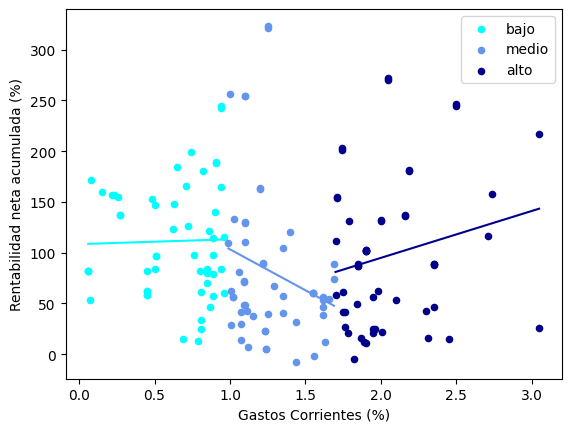

In [19]:
''' Scatterplot con matplotlib '''

color_map = {
    'bajo': 'cyan',
    'medio': 'cornflowerblue',
    'alto': 'darkblue'
}

# obtengo el axis
ax = plt.gca()

for clave, df_group in grouped_df:
    # Scatterplot
    df_group.plot(kind='scatter', x = 'Gastos Corrientes', y='Rentabilidad_total_acumulada', ax=ax,
             color = color_map[clave], label=clave, xlabel='Gastos Corrientes (%)', ylabel= 'Rentabilidad neta acumulada (%)')
    # Línea de tendencia
    coefs = np.polyfit(df_group['Gastos Corrientes'], df_group['Rentabilidad_total_acumulada'], 1)
    tendencia = np.poly1d(coefs)

    # Plot con la línea de tendencia creada
    x_fit = np.linspace(df_group['Gastos Corrientes'].min(), df_group['Gastos Corrientes'].max(), 100)  # Valores de x para la línea de tendencia
    y_fit = tendencia(x_fit)                 # Valores de y correspondientes
    ax.plot(x_fit, y_fit, color=color_map[clave])


Text(0.5, 1.0, 'Rentabilidades según comisión')

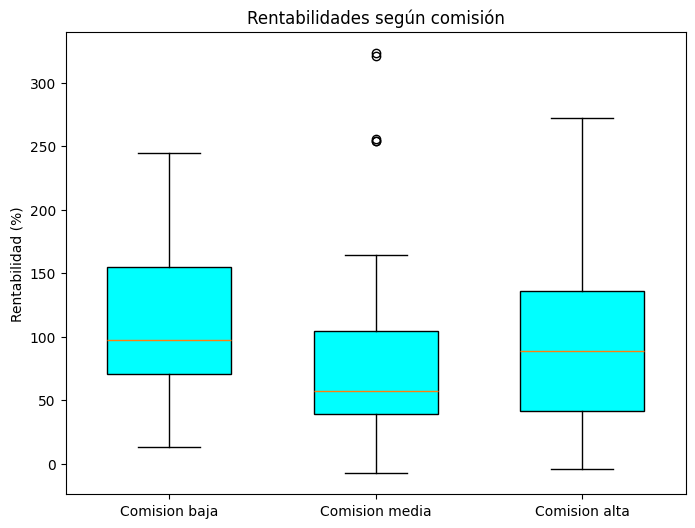

In [20]:
''' Boxplots con matplotlib '''

# Crear la figura y los boxplots
fig, ax = plt.subplots(figsize=(8, 6))

# Crear boxplot para los 3 arrays
ax.boxplot([grouped_df.get_group('bajo')['Rentabilidad_total_acumulada'], grouped_df.get_group('medio')['Rentabilidad_total_acumulada'], 
            grouped_df.get_group('alto')['Rentabilidad_total_acumulada']], widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='cyan'))

# Personalizar el gráfico
ax.set_xticks([1, 2, 3])  # Etiquetas en el eje X
ax.set_xticklabels(['Comision baja', 'Comision media', 'Comision alta'])
ax.set_ylabel('Rentabilidad (%)')
ax.set_title('Rentabilidades según comisión')

#### 4.2 Fondo **ejemplo** y fondo **fracaso**

In [21]:
''' Identificadores de fondo ejemplo y fondo fracaso '''
for clave, group in grouped_df:
    if clave == 'alto':
        rent = group['Rentabilidad_total_acumulada'].min()
        low_rentab_high_incomes_Isin = group.loc[group['Rentabilidad_total_acumulada']==rent, 'ISIN'].values[0]
        print(f'Fondo rentabilidad mala y altos gastos: {rent:.2f}%, ISIN: {low_rentab_high_incomes_Isin}')
    if clave == 'bajo':
        rent2 = group['Rentabilidad_total_acumulada'].max()
        high_rentab_low_incomes_Isin = group.loc[group['Rentabilidad_total_acumulada']==rent2, 'ISIN'].values[0]
        print(f'Fondo rentabilidad buena y bajos gastos: {rent2:.2f}%, ISIN: {high_rentab_low_incomes_Isin}')


Fondo rentabilidad buena y bajos gastos: 244.45%, ISIN: LU0079475348
Fondo rentabilidad mala y altos gastos: -4.28%, ISIN: ES0190052037


Por último, sacamos el identificador del fondo más rentable del dataset. 

In [22]:
df.loc[df['Rentabilidad_total_acumulada']== df['Rentabilidad_total_acumulada'].max(), 'ISIN'].values[0]

'LU0037065595'